In [18]:
import os
import tempfile

import mitsuba as mi
import numpy as np
import drjit as dr
import pytest
import sionna.rt as rt
from sionna.rt import load_scene, Transmitter, PlanarArray, ITURadioMaterial,\
    Receiver, PathSolver, RadioMapSolver, BackscatteringPattern
from sionna.rt.utils import dbm_to_watt, load_mesh, transform_mesh

In [19]:
def default_array(num_rows: int = 1, num_cols: int = 1,
                  vertical_spacing: float = 0.5, horizontal_spacing: float = 0.5,
                  pattern: str = "iso", polarization: str = "V"):
    return PlanarArray(num_rows=num_rows,
                       num_cols=num_cols,
                       vertical_spacing=vertical_spacing,
                       horizontal_spacing=horizontal_spacing,
                       pattern=pattern,
                       polarization=polarization)

In [20]:
def paths_to_coverage_map(paths, is_mesh=False):
    """
    Converts paths into the equivalent coverage map values.
    The coverage map is assumed to be a ssquare.
    """
    # [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
    a_real, a_imag = paths.a
    a = a_real.numpy() + 1j*a_imag.numpy()

    # Transmit precoding
    # Assume default precoding
    # [num_rx, num_rx_ant, num_tx, num_paths]
    a /= np.sqrt(a.shape[3])
    a = np.sum(a, axis=3)

    # Sum energy of paths
    a = np.square(np.abs(a))
    # [num_rx, num_tx]
    a = np.sum(a, axis=(1, 3))

    # Swap dims
    # [num_tx, num_rx]
    a = a.T

    if not is_mesh:
        # Reshape to coverage map
        n = int(np.sqrt(a.shape[1]))
        shape = [a.shape[0], n, n]
        a = np.reshape(a, shape)

    return a

In [21]:
los = True

In [50]:
specular_reflection = True
diffuse_reflection = True
refraction=False
max_depth = 2

# Setup the scene
scene = rt.Scene()
# scene = load_scene(rt.scene.box, merge_shapes=False)
# scene.objects["box"].radio_material = ITURadioMaterial("concrete", "concrete", 0.1)
# scene.objects["box"].radio_material.scattering_coefficient = dr.sqrt(0.5)
# scene.objects["box"].radio_material.scattering_pattern =\
#     BackscatteringPattern(alpha_r=30, alpha_i=10, lambda_=0.5)

scene.tx_array = default_array()
scene.rx_array = default_array(polarization="VH")

scene.add(Transmitter(name="tx",
            position=mi.Point3f(4, 3, 4.0),
            orientation=mi.Point3f(0,0,0),
            display_radius=0.1))
scene.get("tx").look_at(mi.Point3f(0,0,0))

In [51]:
# Load the measurement surface
fname = os.path.join("/Users/jason/Developer/sionna-rt/test/data/subdivided_cube.ply")
ms = load_mesh(fname)
transform_mesh(ms,
                translation=mi.Point3f(0, 0, 2.5),
                scale=mi.Point3f(1.5, 1.5, 1))

# Compute the radio map
rm_solver = RadioMapSolver()
rm_solver.loop_mode = "evaluated"
rm = rm_solver(scene,
            measurement_surface=ms,
            samples_per_tx=int(1e7),
            max_depth=max_depth,
            los=los,
            specular_reflection=specular_reflection,
            diffuse_reflection=diffuse_reflection,
            refraction=refraction)

# Check for NaN or Inf
assert not (dr.any(dr.isinf(rm.path_gain)) or dr.any(dr.isnan(rm.path_gain)))

# Add receivers at the cell centers
for i, pos in enumerate(rm.cell_centers.numpy().T):
    scene.remove(f"rx-{i}")
    scene.add(Receiver(name=f"rx-{i}",
                        position=pos,
                        display_radius=0.1,
                        orientation=mi.Point3f(0, 0, 0)))

# Compute radio map using the path solver
solver = PathSolver()
paths = solver(scene,
                samples_per_src = 10000,
                max_num_paths_per_src=int(1e7),
                max_depth=max_depth,
                los=los,
                specular_reflection=specular_reflection,
                diffuse_reflection=diffuse_reflection,
                refraction=refraction)
a = paths_to_coverage_map(paths, is_mesh=True)[0]

nmse_db = 10*np.log10(np.mean( ((rm.path_gain[0]-a)/a)**2 ))

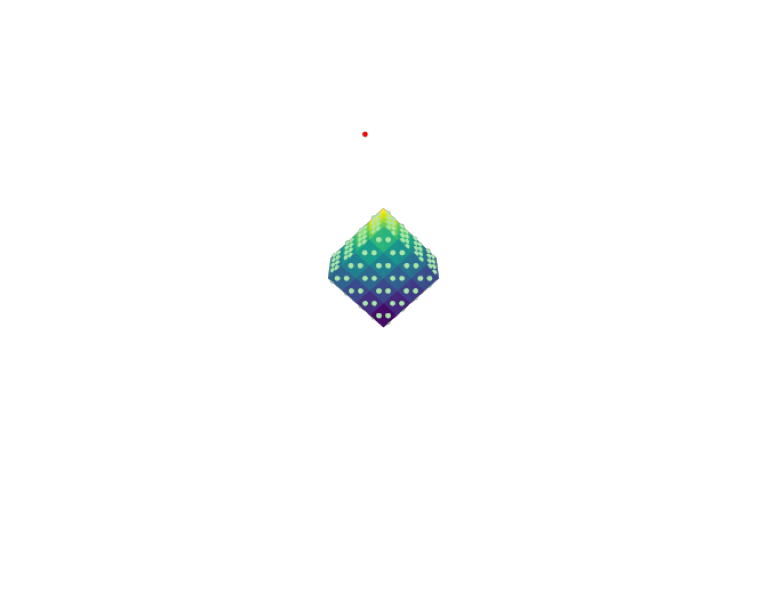

In [52]:
cam = rt.Camera(position=[10, 10, -30], look_at=[0, 0, 0])
scene.render(camera=cam, num_samples=64, show_devices=True, clip_at=0, radio_map=rm, clip_plane_orientation=[0, 0, 1]);

In [53]:
b = rm.path_gain[0].numpy()

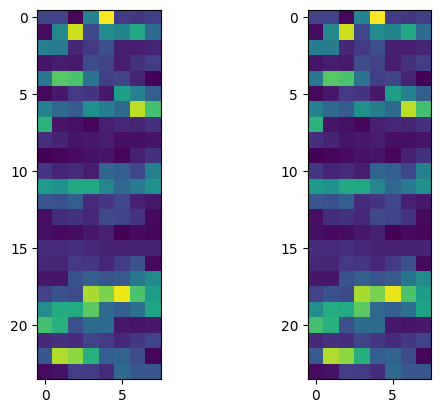

In [54]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(ncols=2)
axs[0].imshow(b.reshape(24, -1))
axs[1].imshow(a.reshape(24, -1))

In [55]:
# import pythreejs as p3js

# scene = p3js.Scene()
# faces = dr.reshape(mi.Point3u, ms.faces_buffer(), (3, -1))
# vertices = dr.reshape(mi.Point3f, ms.vertex_positions_buffer(), (3, -1))
# geo = p3js.BufferGeometry(position=dr.ravel(vertices).numpy())
# mat = p3js.MeshBasicMaterial(color="0xff0000")
# mesh = p3js.Mesh(geo, mat)